In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:\\AshleshaRuchika\\PGCP-AI\\NLP\\Day4\\SMSSpamCollection.csv',sep='\t', names=['label','text'])
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
# seperate the input and output variables

In [4]:
x= df['text']
y= df['label']

In [5]:
#Explore the data

In [6]:
set(y)

{'ham', 'spam'}

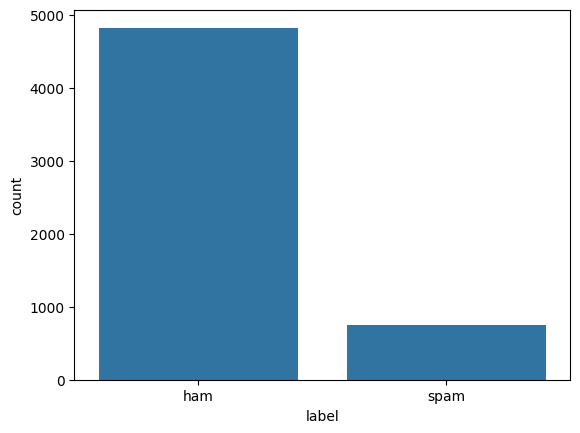

In [7]:
sns.countplot(x=y);

([<matplotlib.patches.Wedge at 0x2123168d7f0>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.59%'),
  Text(0.5475662588910611, -0.24529816983428027, '13.41%')])

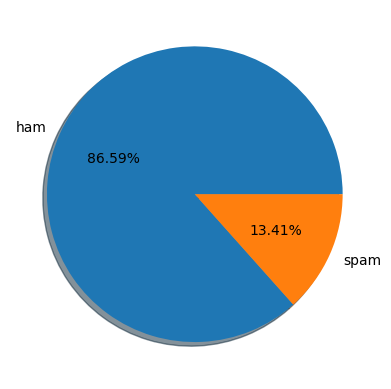

In [8]:
plt.pie(y.value_counts(),labels=['ham','spam'],autopct='%2.2f%%',shadow=True)

## Data Preprocessing

In [9]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer,PorterStemmer
from nltk import pos_tag


In [10]:
sent = 'Hello friends! How are you? I like Python Programming.'

In [11]:
# tokenize the data
tokens1 = word_tokenize(sent)

In [12]:
# remove punctuation and numbers
tokens2 = [token for token in tokens1 if token.isalpha()]

In [13]:
tokens2

['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'Programming']

In [14]:
# remove stopwords
tokens3 = [token.lower() for token in tokens2
          if token.lower() not in stopwords.words('english')]

In [15]:
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [16]:
## apply stemming
ps= PorterStemmer()
tokens4=[ps.stem(token) for token in tokens3]
tokens4

['hello', 'friend', 'like', 'python', 'program']

In [17]:
def clean_text(sent):
    # tokenize the data
    tokens1 = word_tokenize(sent)
    # remove punctuation and numbers
    tokens2 = [token for token in tokens1 if token.isalpha()]
    # remove stopwords
    tokens3 = [token.lower() for token in tokens2
              if token.lower() not in stopwords.words('english')]
    tokens4 = [ps.stem(token) for token in tokens3]
    return tokens4

In [18]:
clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

sent1= 'it '

In [19]:
sent1= 'It was an unexpceted rain during the play on ground.'

In [20]:
clean_text(sent1)

['unexpcet', 'rain', 'play', 'ground']

In [21]:
x.apply(clean_text)

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, wkli, comp, win, fa, cup, final,...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [time, tri, contact, u, pound, prize, claim, e...
5568                       [ü, b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5572, dtype: object

## Vectorization

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf= TfidfVectorizer(analyzer=clean_text)

In [24]:
x_new=tfidf.fit_transform(x)

In [25]:
x_new.shape

(5572, 5925)

In [26]:
tfidf.get_feature_names_out()

array(['aa', 'aah', 'aaniy', ..., 'zyada', 'é', 'ü'],
      shape=(5925,), dtype=object)

In [27]:
len(tfidf.get_feature_names_out())

5925

In [28]:
x_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 5925))

## cross validation

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x_new,y,random_state=0)

In [31]:
x_train.shape

(4179, 5925)

In [32]:
x_test.shape

(1393, 5925)

## Build the model

In [33]:
from sklearn.svm import SVC

In [34]:
svc_lin=SVC(kernel="linear")

In [35]:
svc_lin.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
## performance Evaltuion

In [37]:
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [38]:
y_pred=svc_lin.predict(x_test)

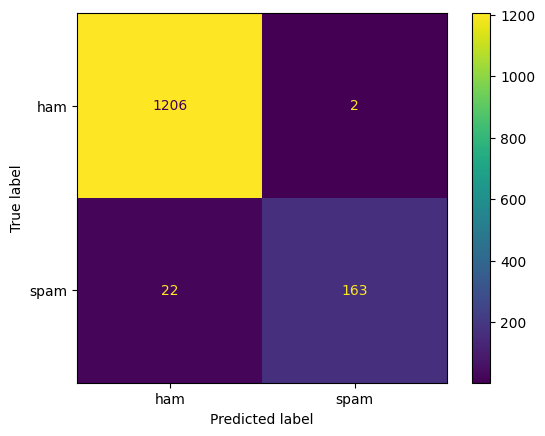

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.88      0.93       185

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [41]:
accuracy_score(y_test,y_pred)

0.9827709978463748

In [42]:
svc_rbf=SVC(kernel="rbf")
svc_rbf.fit(x_train,y_train)
y_pred=svc_rbf.predict(x_test)
accuracy_score(y_test,y_pred)

0.9813352476669059

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       1.00      0.86      0.92       185

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [44]:
svc_poly=SVC(kernel="poly")
svc_poly.fit(x_train,y_train)
y_pred=svc_poly.predict(x_test)
accuracy_score(y_test,y_pred)

0.949748743718593

In [45]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1208
        spam       1.00      0.62      0.77       185

    accuracy                           0.95      1393
   macro avg       0.97      0.81      0.87      1393
weighted avg       0.95      0.95      0.94      1393



In [46]:
svc_sig=SVC(kernel="sigmoid")
svc_sig.fit(x_train,y_train)
y_pred=svc_sig.predict(x_test)
accuracy_score(y_test,y_pred)

0.9798994974874372

In [47]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.98      0.87      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



### Prediction  on unknown sample

In [48]:
f=open("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\Day4\\sample.csv")
lines=f.readlines()

In [49]:
lines

['Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.,,\n',
 'As a valued customer, I am pleased to advise you that following recent review of your Mob No. you are awarded with a Â£1500 Bonus Prize, call 09066364589\n',
 '"Today is ""song dedicated day.."" Which song will u dedicate for me? Send this to all ur valuable frnds but first rply me...",,\n']

In [50]:
new_lines=tfidf.transform(lines)

In [51]:
svc_lin.predict(new_lines)

array(['ham', 'spam', 'ham'], dtype=object)